# Pacific Ridge Realty Pricing Model

You work as a junior data scientist at **Pacific Ridge Realty**, a property analytics team that advises investors on California housing markets. Leadership wants pricing models that are easy to explain to clients, not black-box scores.

Your manager asks you to build a transparent linear regression workflow on the California housing dataset: explore the data, train a baseline model, then a multivariate model, and report $R^2$ on train and test splits. You will use scikit-learn and the patterns from today's linear regression lectures.

## Your mission

Work through the tasks below in order. Each step adds one piece to the pricing pipeline you will present at the end of the day.

In Sklearn, there are datasets that are already pre-recorded that you can use for your projects. You can try the Californian Housing Market dataset first.

### Hints
For each cell to complete, hints are available at **3 levels**. The next cell defines the `fetch_help` function that fetches them for you throughout this exercise. Run it once and do not modify it.

| Level | Call | What you get |
|---|---|---|
| 🟢 1 · Nudge | `fetch_help(4, level=1)` | A reminder of **what** to do |
| 🟡 2 · Hint | `fetch_help(4, level=2)` | **Which function** to use, and why |
| 🔴 3 · Scaffold | `fetch_help(4, level=3)` | The function **with its parameters** |

Before each cell to complete, you will find a `# fetch_help(...)` cell: uncomment it and run it only if you need help. **Start with level 1** and go up only if you are still stuck.

*If you erased the instructions of a cell, `fetch_help(4, content="todo")` gives them back.*

In [71]:
# Hints
# ! pip install -q -U aifs_hints

from aifs_hints import get_helper
fetch_help = get_helper("Machine Learning", "Californian Housing Market")

1. Import the usual libraries

In [72]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import  OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) # to avoid deprecation warnings

import plotly.express as px
import plotly.graph_objects as go
# import plotly.io as pio
# # setting Jedha color palette as default
# pio.templates["jedha"] = go.layout.Template(
#     layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
# )
# #pio.templates.default = "jedha"
# pio.renderers.default = "svg" # to be replaced by "iframe" if working on JULIE


## The dataset

2. Use the following lines of code to retrieve California real estate price data:

In [73]:
from sklearn import datasets
data = datasets.fetch_california_housing(data_home=None, download_if_missing=True, return_X_y=False)

print("type of this dataset object from sklearn:")
display(type(data))
print()
print(data.DESCR)


type of this dataset object from sklearn:


sklearn.utils._bunch.Bunch


.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block 

3. Explore the target values and get the names of the different explanatory variables.

💡 The [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html#sklearn.datasets.fetch_california_housing] may help you 😉

*💡 Stuck? Uncomment and run the `fetch_help(...)` cell just above the cell to complete. Start with `level=1`.*

In [74]:
fetch_help("3a", level=1)

**🟢 Level 1 · Nudge**

The target values are stored **inside the `data` object** you just loaded: find them and display them.

In [75]:
###  Display the target values of the dataset                     ###
display(data.target)
display(data)

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [76]:
# fetch_help("3b", level=1)

In [77]:
###  Display the names of the explanatory variables                ###
display(data.feature_names)


['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

4. You can prefer to have this data in a DataFrame. Use the Pandas library to find a way to put this data into a DataFrame. 

You can go more specifically look at the following link: 

[DataFrame in Pandas](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html)

*💡 Stuck? Uncomment and run the `fetch_help(...)` cell just above the cell to complete. Start with `level=1`.*

In [78]:
fetch_help(4, level=3)

**🔴 Level 3 · Scaffold**

- `pd.DataFrame(data=..., columns=...)` → `data` : `data.data`, `columns` : `data.feature_names`
- New column: `dataset['Price']` ← `data.target`

In [79]:
###  Build a DataFrame named dataset with:                         ###
###   - one column per feature (with the feature names)            ###
###   - a "Price" column containing the target                     ###
###  Then display the first rows                                   ###
dataset = pd.DataFrame(data=data['data'], columns=data['feature_names'])
dataset['Price'] = data['target']
print(dataset.head())
    

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


## EDA

5. Make a bivariate plot of each pair of variables, and analyze the relationship of each variable with the target (_Price_)

*💡 Stuck? Uncomment and run the `fetch_help(...)` cell just above the cell to complete. Start with `level=1`.*

In [80]:
# fetch_help(5, level=1)

In [81]:
# Visualize pairwise dependencies
###  1. Create a scatter matrix of all the columns of dataset       ###
###  2. Give it a title and a size big enough to be readable       ###
###  3. Display the figure                                        ###

fig = px.scatter_matrix(dataset, dimensions=dataset.columns, title="Bivariate analysis")
fig.update_layout(width=1000, height=1000)
fig.show()


6. There seem to be some correlations between some features and the target, but the plot are a bit deteriorated by the presence of outliers. You can filter out these outliers:
* Create a mask that allows to keep lines with : _AveRooms_ < 10 ; _AveBedrms_ < 10 ; _Population_ < 15000 ; _AveOccup_ < 10 and _Price_ < 5
* Use this mask to filter out the outliers from your dataset and make a new bivariate plot
* Do you see anything interesting ?

*💡 Stuck? Uncomment and run the `fetch_help(...)` cell just above the cell to complete. Start with `level=1`.*

In [82]:
# fetch_help(6, level=1)

In [83]:
###  1. Create a boolean mask that keeps the rows where:            ###
###     AveRooms < 10, AveBedrms < 10, Population < 15000,         ###
###     AveOccup < 10 and Price < 5                               ###
###  2. Apply the mask to dataset                                 ###
###  3. Make the same scatter matrix as before on the filtered data ###
mask = (dataset['AveRooms'] < 10) & \
       (dataset['AveBedrms'] < 10) & \
       (dataset['Population'] < 15000) & \
       (dataset['AveOccup'] < 10) & \
       (dataset['Price'] < 5)

filtered_dataset = dataset[mask]

fig = px.scatter_matrix(filtered_dataset, dimensions=filtered_dataset.columns, \
                        title="Bivariate analysis 2 avec data filtrées")

fig.update_layout(width=1000, height=1000)
fig.show() 

7. The median income seems to be correlated to the target, but it's not obvious for the other variables. You can confirm this by plotting the correlation matrix:

*💡 Stuck? Uncomment and run the `fetch_help(...)` cell just above the cell to complete. Start with `level=1`.*

In [84]:
fetch_help(7, level=2)

**🟡 Level 2 · Hint**

- pandas computes the correlation matrix of a DataFrame with `.corr()`.
- `px.imshow` displays a 2D table as a heatmap.

In [85]:
# Correlation matrix
###  1. Compute the correlation matrix of dataset (round it)        ###
###  2. Plot it as a heatmap, with the column names on both axes    ###
###  3. Display the figure                                        ###
correlated = filtered_dataset.corr().round(2)
fig = px.imshow(correlated, text_auto=True, aspect="auto", title="Correlation Matrix")
fig.show()

The correlation between the median income and the target is quite high ! This is a good news, it suggests that you might be able to predict the values of the price with a good precision if you include this variable in the model's features. Some other variables might be useful as well: _AveRooms_, _AveOccup_ and _Latitude_. In the following, you will create a baseline model with only _MedInc_, and then compare the performances with the ones reached by using all the variables together.

## Baseline model

8. For your baseline, you will only use the _MedInc_ variable as an input feature. Create a variable X containing the values of this features, and a variable Y containing the values of the target.

*💡 Stuck? Uncomment and run the `fetch_help(...)` cell just above the cell to complete. Start with `level=1`.*

In [86]:
# fetch_help(8, level=1)

In [87]:
# Separate target variable Y from features X
print("Separating labels from features...")

###  1. Store the list of features to use (only "MedInc") in       ###
###     features_list, and the target name ("Price") in           ###
###     target_variable                                           ###
###  2. X = the features_list columns of dataset                  ###
###  3. Y = the target column                                     ###
features_list = ["MedInc"]
target_variable = "Price"
X = filtered_dataset[features_list]
Y = filtered_dataset[target_variable]
print("...Done.")
print()

print('Y : ')
print(Y.head())
print()
print('X :')
print(X.head())

Separating labels from features...
...Done.

Y : 
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64

X :
   MedInc
0  8.3252
1  8.3014
2  7.2574
3  5.6431
4  3.8462


9. Make a train/test splitting (keep 80% of the dataset for model training).

*💡 Stuck? Uncomment and run the `fetch_help(...)` cell just above the cell to complete. Start with `level=1`.*

In [88]:
# fetch_help(9, level=1)

In [89]:
# Divide dataset Train set & Test set
print("Dividing into train and test sets...")
from sklearn.model_selection import train_test_split

###  Split X and Y into X_train, X_test, Y_train, Y_test           ###
###  (80% train / 20% test)                                        ###
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
print("...Done.")
print()

Dividing into train and test sets...
(15518, 1) (3880, 1)
...Done.



10. What preprocessings are necessary here? Apply it to X_train and X_test

*💡 Stuck? Uncomment and run the `fetch_help(...)` cell just above the cell to complete. Start with `level=1`.*

In [90]:
# Basic stats
print("Number of rows : {}".format(filtered_dataset.shape[0]))
print()

print("Display of dataset: ")
display(filtered_dataset.head())
print()

print("Basics statistics: ")
data_desc = filtered_dataset.describe(include='all')
display(data_desc)
print()

print("Percentage of missing values: ")
display(100*filtered_dataset.isnull().sum()/filtered_dataset.shape[0])


Number of rows : 19398

Display of dataset: 


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Basics statistics: 


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,19398.000000,19398.000000,19398.000000,19398.000000,19398.000000,19398.000000,19398.000000,19398.000000,19398.000000
mean,3.674497,28.496907,5.210648,1.066038,1442.172080,2.944640,35.637872,-119.567484,1.924128
std,1.563397,12.477953,1.168098,0.128846,1077.498768,0.766194,2.142960,2.004793,0.971784
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.750000,32.540000,-124.350000,0.149990
25%,2.525900,18.000000,4.407329,1.005413,805.000000,2.450413,33.930000,-121.770000,1.167000
50%,3.447800,29.000000,5.170038,1.047619,1185.500000,2.842105,34.260000,-118.490000,1.741000
75%,4.583175,37.000000,5.944617,1.096884,1752.000000,3.308127,37.720000,-118.000000,2.485000
max,15.000100,52.000000,9.979167,3.411111,13251.000000,9.954545,41.950000,-114.550000,4.991000



Percentage of missing values: 


MedInc        0.0
HouseAge      0.0
AveRooms      0.0
AveBedrms     0.0
Population    0.0
AveOccup      0.0
Latitude      0.0
Longitude     0.0
Price         0.0
dtype: float64

**You have only numeric features with no missing values, so here the preprocessing is very simple: you just want to standardize all the columns!**

In [91]:
# fetch_help("10a", level=1)

In [92]:
print("Preprocessing X_train...")
print(X_train.head())
print()

###  Standardize all the columns of X_train                        ###
###  1. Instantiate a StandardScaler                              ###
###  2. Fit it AND transform X_train in a single step             ###
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)


print("...Done!")
print(X_train[0:5,:]) # X_train is now a numpy array

Preprocessing X_train...
       MedInc
15015  2.9624
2823   5.5261
2795   2.3250
1360   3.3661
12795  1.5600

...Done!
[[-0.45883376]
 [ 1.1903096 ]
 [-0.86885209]
 [-0.19914692]
 [-1.36095127]]


In [93]:
# fetch_help("10b", level=1)

In [94]:
print("Preprocessing X_test...")
print(X_test.head())
print()

###  Standardize X_test using the scaler fitted on X_train          ###
X_test = scaler.transform(X_test)

print("...Done!")
print(X_test[0:5,:]) # X_test is now a numpy array

Preprocessing X_test...
       MedInc
13065  4.5766
2516   3.0469
12039  3.3187
17668  3.2806
2426   2.2206

...Done!
[[ 0.57952767]
 [-0.40447771]
 [-0.22963777]
 [-0.25414624]
 [-0.93600915]]


11. Train the baseline model and print out its R2-score on train set and test set

*💡 Stuck? Uncomment and run the `fetch_help(...)` cell just above the cell to complete. Start with `level=1`.*

In [95]:
# fetch_help("11a", level=1)

In [96]:
# Train model
print("Train model...")

###  1. Instantiate a LinearRegression model named regressor        ###
###     (it's used in the next cells)                             ###
###  2. Fit it on the training set (X_train, Y_train)              ###
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, Y_train)

print("...Done.")

Train model...
...Done.


In [97]:
# fetch_help("11b", level=1)

In [98]:
# Print R^2 scores
###  Complete the two prints with the R2 score of regressor        ###
###  on the training set and on the test set                       ###
print("R2 score on training set : ", regressor.score(X_train, Y_train))

print("R2 score on test set : ", regressor.score(X_test, Y_test))

R2 score on training set :  0.4167165274921717
R2 score on test set :  0.4344122018672747


12. Plot the model's predictions

*💡 Stuck? Uncomment and run the `fetch_help(...)` cell just above the cell to complete. Start with `level=1`.*

In [99]:
# fetch_help("12a", level=1)

In [100]:
# Predictions on training set
print("Predictions on training set...")

###  Use the trained regressor to predict on X_train               ###
###  Store the result in Y_train_pred                              ###
Y_train_pred = regressor.predict(X_train)

print("...Done.")
print(Y_train_pred)
print()

Predictions on training set...
...Done.
[1.63713472 2.66860053 1.3806865  ... 2.85926701 2.19919649 2.15405452]



In [101]:
# fetch_help("12b", level=1)

In [102]:
# Predictions on test set
print("Predictions on test set...")

###  Use the same trained regressor to predict on X_test           ###
###  Store the result in Y_test_pred                               ###
Y_test_pred = regressor.predict(X_test)

print("...Done.")
print(Y_test_pred)
print()

Predictions on test set...
...Done.
[2.28658361 1.67113202 1.78048663 ... 2.46039226 2.85926701 1.45829689]



In [103]:
fetch_help("12c", level=3)

**🔴 Level 3 · Scaffold**

- Points: `px.scatter(x=..., y=Y_train, title=...)`
- Line: `fig.add_trace(go.Scatter(x=..., y=Y_train_pred, name=...))`
- `x` : `X_train.flatten().tolist()`

In [112]:
# Visualize the model

# Visualize predictions on training set
###  1. Scatter plot of the real values: x = X_train, y = Y_train  ###
###  2. Add the regression line on top, with Y_train_pred as y     ###
###  3. Display the figure                                        ###
#import matplotlib.pyplot as plt

fig = px.scatter( x=X_train.flatten(), y=Y_train, title= "Training set",)

fig.add_scatter(x=X_train.flatten(), y=Y_train_pred, mode='lines', name='Predictions', line=dict(color='red'))

fig.show()

## Multivariate model
Our baseline is already performing way better than a "dummy" model, but you can see if you can improve the score by including all the explanatory variables in your model.

13. Train a multivariate model by including all the features

*💡 Stuck? Uncomment and run the `fetch_help(...)` cell just above the cell to complete. Start with `level=1`.*

In [105]:
# fetch_help("13a", level=1)

In [114]:
# Separate target variable Y from features X
print("Separating labels from features...")

###  1. Store the name of the target column ("Price") in           ###
###     a variable target_variable                                ###
###  2. X = all columns except the target                         ###
###  3. Y = only the target column                                ###
target_variable = "Price"
X = dataset.drop(columns=target_variable)
Y = dataset[target_variable]

print("...Done.")
print()

print('Y : ')
print(Y.head())
print()
print('X :')
print(X.head())

Separating labels from features...
...Done.

Y : 
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64

X :
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [107]:
# fetch_help("13b", level=1)

In [115]:
# Divide dataset Train set & Test set
print("Dividing into train and test sets...")

###  Split X and Y into X_train, X_test, Y_train, Y_test           ###
###  (80% train / 20% test, same random_state as the baseline)     ###
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


print("...Done.")
print()

Dividing into train and test sets...
...Done.



In [109]:
# fetch_help("13c", level=1)

In [116]:
# Preprocessing
print("Preprocessing X_train...")
print(X_train.head())
print()

###  Standardize all the columns of X_train (fit + transform)      ###
numeric_features = X_train.columns.tolist()   #

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
    ]
)

X_train = preprocessor.fit_transform(X_train)

print("...Done!")
print(X_train[0:5,:]) # X_train is now a numpy array

Preprocessing X_train...
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
14196  3.2596      33.0  5.017657   1.006421      2300.0  3.691814     32.71   
8267   3.8125      49.0  4.473545   1.041005      1314.0  1.738095     33.77   
17445  4.1563       4.0  5.645833   0.985119       915.0  2.723214     34.66   
14265  1.9425      36.0  4.002817   1.033803      1418.0  3.994366     32.69   
2271   3.5542      43.0  6.268421   1.134211       874.0  2.300000     36.78   

       Longitude  
14196    -117.03  
8267     -118.16  
17445    -120.48  
14265    -117.11  
2271     -119.80  

...Done!
[[-0.326196    0.34849025 -0.17491646 -0.20836543  0.76827628  0.05137609
  -1.3728112   1.27258656]
 [-0.03584338  1.61811813 -0.40283542 -0.12853018 -0.09890135 -0.11736222
  -0.87669601  0.70916212]
 [ 0.14470145 -1.95271028  0.08821601 -0.25753771 -0.44981806 -0.03227969
  -0.46014647 -0.44760309]
 [-1.01786438  0.58654547 -0.60001532 -0.14515634 -0.00743434  0.07

In [ ]:
# fetch_help("13d", level=1)

In [118]:
print("Preprocessing X_test...")
print(X_test.head())
print()

###  Standardize X_test using the scaler fitted on X_train          ###
numeric_features = X_test.columns.tolist()   #
X_test = preprocessor.transform(X_test)

print("...Done!")
print(X_test[0:5,:]) # X_test is now a numpy array

Preprocessing X_test...
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
20046  1.6812      25.0  4.192201   1.022284      1392.0  3.877437     36.06   
3024   2.5313      30.0  5.039384   1.193493      1565.0  2.679795     35.14   
15663  3.4801      52.0  3.977155   1.185877      1310.0  1.360332     37.80   
20484  5.7376      17.0  6.163636   1.020202      1705.0  3.444444     34.28   
9814   3.7250      34.0  5.492991   1.028037      1063.0  2.483645     36.62   

       Longitude  
20046    -119.01  
3024     -119.46  
15663    -122.44  
20484    -118.72  
9814     -121.93  

...Done!
[[-1.15508475 -0.28632369 -0.52068576 -0.17174603 -0.03030109  0.06740798
   0.1951      0.28534728]
 [-0.70865905  0.11043502 -0.16581537  0.22347203  0.12185077 -0.03602975
  -0.23549054  0.06097472]
 [-0.21040155  1.85617335 -0.61076476  0.20589202 -0.10241931 -0.14998876
   1.00947776 -1.42487026]
 [ 0.97511311 -0.92113763  0.3051148  -0.17655235  0.24497944  0.030

In [ ]:
# fetch_help("13e", level=1)

In [119]:
# Train model
print("Train model...")

###  Instantiate a new LinearRegression named regressor and fit it ###
###  on the training set                                           ###
regressor = LinearRegression()
regressor.fit(X_train, Y_train)

print("...Done.")

Train model...
...Done.


In [ ]:
# fetch_help("13f", level=1)

In [120]:
# Print R^2 scores
###  Complete the two prints with the R2 score of regressor        ###
###  Then compare them with the baseline model                     ###
print("R2 score on training set : ", regressor.score(X_train, Y_train))
print("R2 score on test set : ", regressor.score(X_test, Y_test))

R2 score on training set :  0.6125511913966952
R2 score on test set :  0.5757877060324508


Adding more variables in your model significantly improved the R2-score 🥳

## Feature importance

You can analyze what features are important for the prediction.

14. Extract the model's coefficients and conclude about the important features

*💡 Stuck? Uncomment and run the `fetch_help(...)` cell just above the cell to complete. Start with `level=1`.*

In [124]:
fetch_help("14a", level=3)

**🔴 Level 3 · Scaffold**

`pd.DataFrame(index=column_names, data=regressor.coef_, columns=['coefficients'])`

In [129]:
###  1. Store the names of the features in column_names             ###
###  2. Create a DataFrame coefs with one row per feature and       ###
###     its coefficient in the model                              ###
###  3. Display coefs                                             ###
column_names = X.columns.tolist()
coefs = pd.DataFrame(index=column_names, data=regressor.coef_, columns=["coefficients"])
print(coefs)

            coefficients
MedInc          0.854383
HouseAge        0.122546
AveRooms       -0.294410
AveBedrms       0.339259
Population     -0.002308
AveOccup       -0.040829
Latitude       -0.896929
Longitude      -0.869842


In [130]:
fetch_help("14b", level=1)

**🟢 Level 1 · Nudge**

- Rank the features by **importance** = size of the coefficient, **whatever its sign**
- Plot them in a horizontal bar chart
- 👀 Why can you compare the coefficients with each other here?

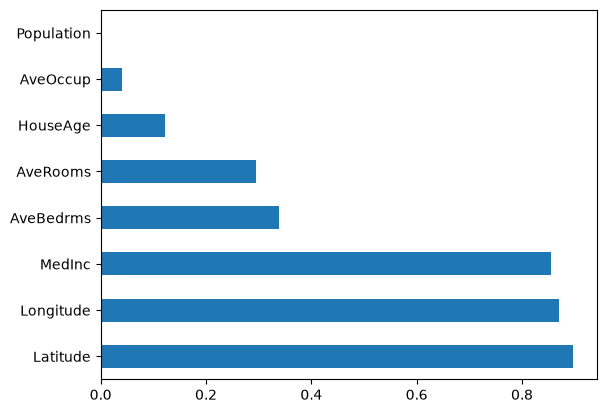

In [131]:
###  1. Compute the absolute value of the coefficients and sort them ###
###  2. Plot them in a horizontal bar chart                        ###
###  3. Remove the legend and add a left margin for the labels     ###
###  4. Display the figure                                        ###
coefs_abs = coefs["coefficients"].abs().sort_values()
coefs_abs.plot(kind="barh", legend=False)
plt.gca().invert_yaxis()
plt.show()


**Conclusion : the most important features are Latitude, Longitude, MedInc and AveOccup. It's interesting to notice that the model doesn't necessarily rank the features according to the values of the correlation coefficients. The reason why is that the correlation coefficient probes the linear relationship between the target and ONE feature at a time, whereas the model looks for the best COMBINATION of features.**